Calcular el solapamiento m de dos patrones para cada paso montecarlo de la forma:

\begin{equation}
\nonumber
m(s)=\frac{1}{N^2a(1-a)}\sum_{i=1}^N\sum_{j=1}^N(\epsilon_{i,j}-a)(s_{i,j}-a)

\end{equation}

\begin{equation}
\nonumber

a=\frac{1}{N^2}\sum_{i=1}^N\sum_{j=1}^N\epsilon_{i,j}

\end{equation}

Ejercicio 1. Cálculo de los fichero de solapamiento m para cada paso Monte Carlo del estado de la neurona partiendo de una configuración inicial aleatoria y una configuración inicial deformada, con el patrón almacenado. 

In [47]:
import numpy as np


#Leo el fichero donde he guardado las s y las epsilon de cada paso montecarlo
N=150

#Cargar los datos del patrón incial 

def leer_patron_binario(nombre_archivo):

    N=150

    # Crea una matriz N x N llena de 0 con NumPy
    matriz = np.zeros((N, N))

    # Leo el archivo y llena la matriz, 

    with open(nombre_archivo) as archivo: # Abre el archivo para lectura
        for i in range(N):
            for j in range(N):
                c = archivo.read(1) # Lee un carácter del archivo

                # Saltar espacios y saltos de línea
                while c and c.isspace(): #c.isspace() devuelve True si c es un espacio, tabulación o salto de línea
                    c = archivo.read(1) # Lee el siguiente carácter del archivo

                if c == "0":
                    matriz[i][j] = 0
                else:
                    matriz[i][j] = 1

    return matriz

#Cargar el patron inicial en una matriz

epsilon = leer_patron_binario("patron_binario.txt") 
 
s_aleatorio=np.loadtxt("neuronas_aleatorios.txt") #Estados para inicio aleatorio

s_patron_deformado=np.loadtxt("deformado.txt") #Estados para inicio deformado

# Reorganizo los datos en bloques (num_pasos, N, N)
estados_aleatorio = s_aleatorio.reshape(-1, N, N)
estados_deformado = s_patron_deformado.reshape(-1, N, N)


#Genero una función para calcular el solapamiento entre el patron s de cada paso montecarlo con mi patron epsilon

def solapamiento(s, epsilon):
    # Primero calcular a (una sola vez)
    a = np.sum(epsilon) / (N * N)
    
    # Luego calcular m usando el valor de a
    m = 0.0
    for i in range(0, N): 
        for j in range(0, N):
            m = m + (1.0 / (N*N*a*(1-a))) * (epsilon[i][j] - a) * (s[i][j] - a)
    
    return m


with open("m_aleatorio.txt", "w") as fich_aleatorio, open("m_deformado.txt", "w") as fich_deformado:
    for i in range(0, estados_aleatorio.shape[0]):

        #Patron inicial para s aleatorio

        s_aleatorio=estados_aleatorio[i, :, :]
        m_aleatorio=solapamiento(s_aleatorio, epsilon)

        #Patron inicial para s deformado

        s_deformado=estados_deformado[i, :, :]
        m_deformado=solapamiento(s_deformado, epsilon)

        
        # Guardo cada m en un fichero junto con el tiempo al que corresponde
    
        fich_aleatorio.write(f"{i} {m_aleatorio}\n")
        fich_deformado.write(f"{i} {m_deformado}\n")

1.Representación del solapamiento m para cada paso Monte Carlo

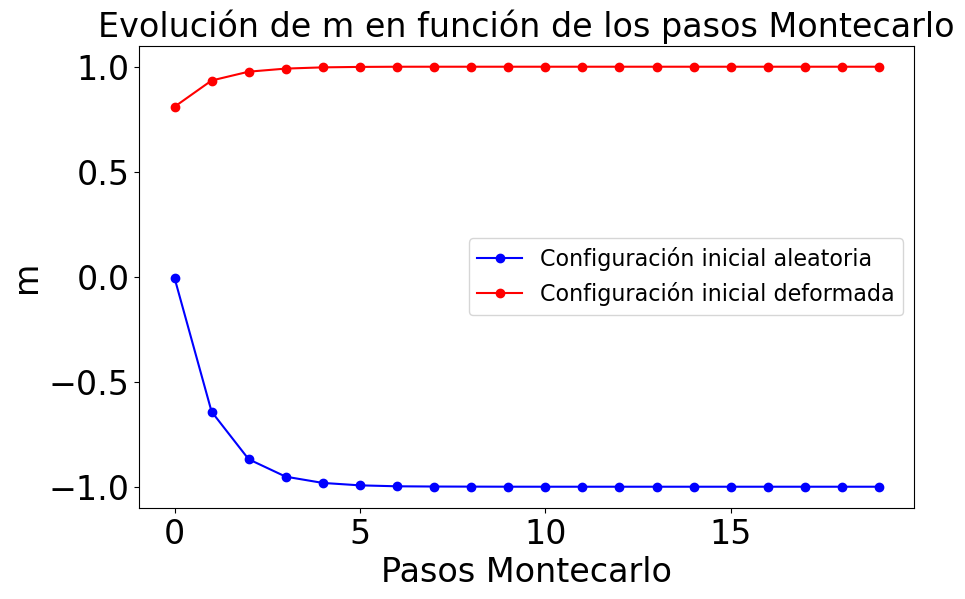

In [48]:
import numpy as np
import matplotlib.pyplot as plt

#Cargo los datos del solapamiento para cada paso montecarlo

m_aleatorio=np.loadtxt("m_aleatorio.txt")
m_deformado=np.loadtxt("m_deformado.txt")

#Creo la gráfica donde se representa la m_aleatoria y la m_deformada en una misma
#gráfica en función del tiempo (pasos montecarlo)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(m_aleatorio[:, 0], m_aleatorio[:, 1], marker="o", color="blue", label="Configuración inicial aleatoria")
ax.plot(m_deformado[:, 0], m_deformado[:, 1], marker="o", color="red", label="Configuración inicial deformada")
ax.set_xlabel("Pasos Montecarlo", fontsize=24)
ax.set_ylabel("m", fontsize=24)
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)
ax.set_title("Evolución de m en función de los pasos Montecarlo", fontsize=24)
ax.legend(fontsize=16)
plt.show()



EJERCICIO 2. Solapamiento para distintas temperaturas

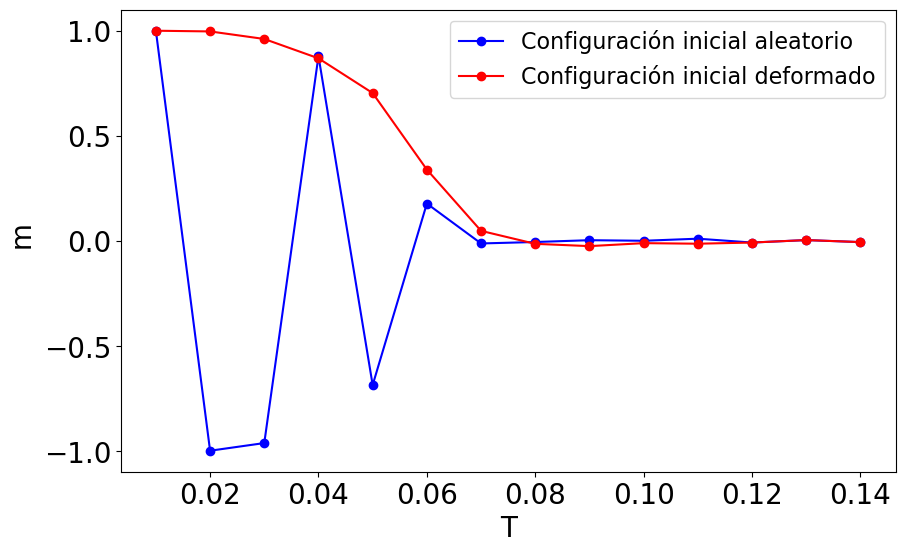

In [3]:
import numpy as np
import matplotlib.pyplot as plt
N = 150
#Calculo el solapamiento del último paso montecarlo para cada temperatura con el patrón epsilon

#Extraigo la última matriz del txt correspondiente al último paso montecarlo para cada temperatura
n_a_T_0_01 = np.loadtxt("neuronas_aleatorios_T_0.01.txt")
ultima_matriz_n_a_T_0_01 = n_a_T_0_01.reshape(20, N, N)[-1]

n_a_T_0_02 = np.loadtxt("neuronas_aleatorios_T_0.02.txt")
ultima_matriz_n_a_T_0_02 = n_a_T_0_02.reshape(20, N, N)[-1]

n_a_T_0_03 = np.loadtxt("neuronas_aleatorios_T_0.03.txt")
ultima_matriz_n_a_T_0_03 = n_a_T_0_03.reshape(20, N, N)[-1]

n_a_T_0_04 = np.loadtxt("neuronas_aleatorios_T_0.04.txt")
ultima_matriz_n_a_T_0_04 = n_a_T_0_04.reshape(20, N, N)[-1]

n_a_T_0_05= np.loadtxt("neuronas_aleatorios_T_0.05.txt")
ultima_matriz_n_a_T_0_05 = n_a_T_0_05.reshape(20, N, N)[-1]

n_a_T_0_06= np.loadtxt("neuronas_aleatorios_T_0.06.txt")
ultima_matriz_n_a_T_0_06 = n_a_T_0_06.reshape(20, N, N)[-1]

n_a_T_0_07= np.loadtxt("neuronas_aleatorios_T_0.07.txt")
ultima_matriz_n_a_T_0_07 = n_a_T_0_07.reshape(20, N, N)[-1]

n_a_T_0_08= np.loadtxt("neuronas_aleatorios_T_0.08.txt")
ultima_matriz_n_a_T_0_08 = n_a_T_0_08.reshape(20, N, N)[-1]

n_a_T_0_09 = np.loadtxt("neuronas_aleatorios_T_0.09.txt")
ultima_matriz_n_a_T_0_09 = n_a_T_0_09.reshape(20, N, N)[-1]

n_a_T_0_1= np.loadtxt("neuronas_aleatorios_T_0.1.txt")
ultima_matriz_n_a_T_0_1 = n_a_T_0_1.reshape(20, N, N)[-1]

n_a_T_0_11= np.loadtxt("neuronas_aleatorios_T_0.11.txt")
ultima_matriz_n_a_T_0_11 = n_a_T_0_11.reshape(20, N, N)[-1]

n_a_T_0_12= np.loadtxt("deformado_T_0.12.txt")
ultima_matriz_n_a_T_0_12 = n_a_T_0_12.reshape(20, N, N)[-1]

n_a_T_0_13= np.loadtxt("deformado_T_0.13.txt")
ultima_matriz_n_a_T_0_13 = n_a_T_0_13.reshape(20, N, N)[-1]

n_a_T_0_14= np.loadtxt("deformado_T_0.14.txt")
ultima_matriz_n_a_T_0_14 = n_a_T_0_14.reshape(20, N, N)[-1]




n_d_T_0_01= np.loadtxt("deformado_T_0.01.txt")
ultima_matriz_n_d_T_0_01 = n_d_T_0_01.reshape(20, N, N)[-1]

n_d_T_0_02= np.loadtxt("deformado_T_0.02.txt")
ultima_matriz_n_d_T_0_02 = n_d_T_0_02.reshape(20, N, N)[-1]

n_d_T_0_03= np.loadtxt("deformado_T_0.03.txt")
ultima_matriz_n_d_T_0_03 = n_d_T_0_03.reshape(20, N, N)[-1]

n_d_T_0_04= np.loadtxt("deformado_T_0.04.txt")
ultima_matriz_n_d_T_0_04 = n_d_T_0_04.reshape(20, N, N)[-1]

n_d_T_0_05= np.loadtxt("deformado_T_0.05.txt")
ultima_matriz_n_d_T_0_05 = n_d_T_0_05.reshape(20, N, N)[-1]

n_d_T_0_06= np.loadtxt("deformado_T_0.06.txt")
ultima_matriz_n_d_T_0_06 = n_d_T_0_06.reshape(20, N, N)[-1]

n_d_T_0_07= np.loadtxt("deformado_T_0.07.txt")
ultima_matriz_n_d_T_0_07 = n_d_T_0_07.reshape(20, N, N)[-1]

n_d_T_0_08= np.loadtxt("deformado_T_0.08.txt")
ultima_matriz_n_d_T_0_08 = n_d_T_0_08.reshape(20, N, N)[-1]

n_d_T_0_09 = np.loadtxt("deformado_T_0.09.txt")
ultima_matriz_n_d_T_0_09 = n_d_T_0_09.reshape(20, N, N)[-1]

n_d_T_0_1= np.loadtxt("deformado_T_0.1.txt")
ultima_matriz_n_d_T_0_1 = n_d_T_0_1.reshape(20, N, N)[-1]

n_d_T_0_11= np.loadtxt("deformado_T_0.11.txt")
ultima_matriz_n_d_T_0_11 = n_d_T_0_11.reshape(20, N, N)[-1]

n_d_T_0_12= np.loadtxt("deformado_T_0.12.txt")
ultima_matriz_n_d_T_0_12 = n_d_T_0_12.reshape(20, N, N)[-1]

n_d_T_0_13= np.loadtxt("deformado_T_0.13.txt")
ultima_matriz_n_d_T_0_13 = n_d_T_0_13.reshape(20, N, N)[-1]

n_d_T_0_14= np.loadtxt("deformado_T_0.14.txt")
ultima_matriz_n_d_T_0_14 = n_d_T_0_14.reshape(20, N, N)[-1]

#LLamo al patrón inicial epsilon

epsilon = np.loadtxt("patron_binario.txt")

#Calcula el solapamiento para cada temperatura con el patrón epsilon

def solapamiento(s, epsilon, N):
    # Primero calcular a (una sola vez)
    a = np.sum(epsilon) / (N * N)
    
    # Luego calcular m usando el valor de a
    m = 0.0
    for i in range(0, N): 
        for j in range(0, N):
            m = m + (1.0 / (N*N*a*(1-a))) * (epsilon[i][j] - a) * (s[i][j] - a)
    
    return m

#Genero un array con los valores del solapamiento del ultimo paso montecarlo para cada temepratura

m_aleatorio = [solapamiento(ultima_matriz_n_a_T_0_01, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_02, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_03, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_04, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_05, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_06, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_07, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_08, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_09, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_1, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_11, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_12, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_13, epsilon, N), solapamiento(ultima_matriz_n_a_T_0_14, epsilon, N)]
m_deformado = [solapamiento(ultima_matriz_n_d_T_0_01, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_02, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_03, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_04, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_05, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_06, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_07, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_08, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_09, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_1, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_11, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_12, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_13, epsilon, N), solapamiento(ultima_matriz_n_d_T_0_14, epsilon, N)]
#Genero un array de temperaturas 

T=[0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1, 0.11, 0.12, 0.13, 0.14]
#*******************Grafico m en función de T*************************

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(T, m_aleatorio, marker="o", color="blue", label="Configuración inicial aleatorio")
ax.plot(T, m_deformado, marker="o", color="red", label="Configuración inicial deformado")
ax.set_xlabel("T", fontsize=20)
ax.set_ylabel(" m", fontsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.legend(fontsize=16)






EJERICIO 3

Calculo el solapamiento varios patrones.\\
\begin{equation}
\nonumber
m^{\mu}(s)=\frac{1}{N^2a^{\mu}(1-a^{\mu})}\sum_{i=1}^N\sum_{j=1}^N(\epsilon_{i,j}^{\mu}-a^{\mu})(s_{i,j}-a^{\mu})
\end{equation}

\begin{equation}
\nonumber

a^{\mu}=\frac{1}{N^2}\sum_{i=1}^N\sum_{j=1}^N\epsilon_{i,j}^{\mu}

\end{equation}

Para una temperatura concreta

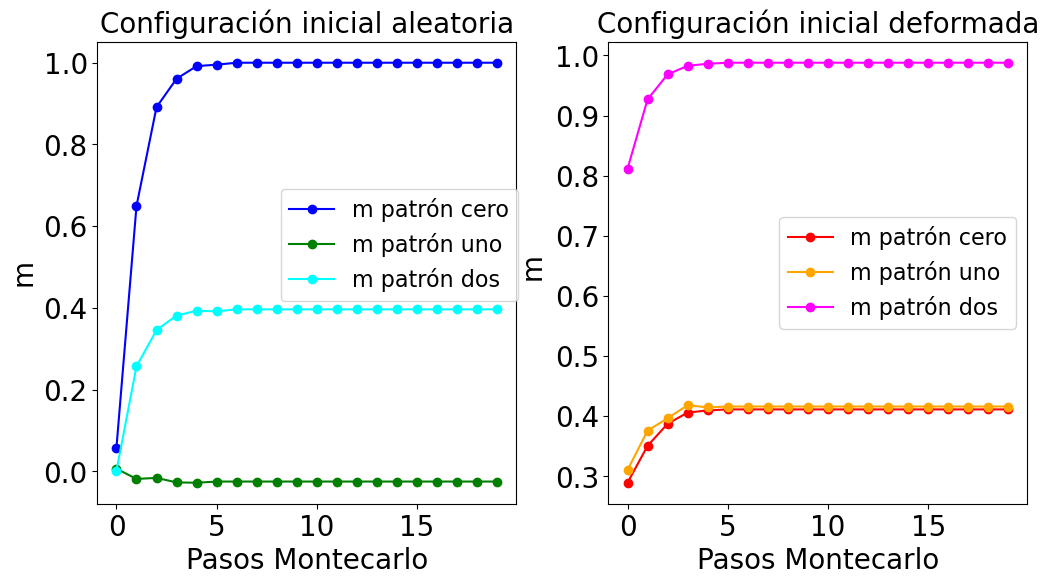

In [39]:
import numpy as np
import matplotlib.pyplot as plt

#Leo el fichero donde he guardado las s y las epsilon de cada paso montecarlo
N=30
cero=np.loadtxt("0_m.txt") #Estados para inicio con patrón de ceros
uno=np.loadtxt("1_m.txt") #Estados para inicio con patrón de unos
dos=np.loadtxt("2_m.txt") #Estados para inicio con patrón de dos

# Genero un vector de patrones iniciales, cada elemento es una matriz

patrones_iniciales = [cero, uno, dos]
 

estados_aleatorio=np.loadtxt("neuronas_aleatorios_varios_patrones_m.txt") 

estados_deformado=np.loadtxt("deformado_varios_patrones_m.txt")
 
 

# Reorganizo los datos en bloques (num_pasos, N, N)
s_aleatorio = estados_aleatorio.reshape(-1, N, N)
s_deformado = estados_deformado.reshape(-1, N, N)


#Genero una función para calcular el solapamiento entre el patron s de cada paso montecarlo con mi patron epsilon

def solapamiento(s, patrones_iniciales):
    # Primero calcular a (una sola vez)
    a = np.zeros(len(patrones_iniciales))
    for mu in range(len(patrones_iniciales)):
        a[mu] = np.sum(patrones_iniciales[mu]) / (N * N)

    # Luego calcular m usando el valor de a
    m =np.zeros(len(patrones_iniciales))
    for i in range(0, N): 
        for j in range(0, N):
            for mu in range(len(patrones_iniciales)):
                m[mu] = m[mu] + (1.0 / (N*N*a[mu]*(1-a[mu]))) * (patrones_iniciales[mu][i][j] - a[mu]) * (s[i][j] - a[mu])
    
    return m


with open("m_aleatorio_varios_patrones_m.txt", "w") as fich_aleatorio, open("m_deformado_varios_patrones_m.txt", "w") as fich_deformado:
    fich_aleatorio.write("# paso m_cero m_uno m_dos\n")
    fich_deformado.write("# paso m_cero m_uno m_dos\n")
    for i in range(s_aleatorio.shape[0]):

        #Patron inicial para s aleatorio

        s_aleatorio_i = s_aleatorio[i, :, :]
        m_aleatorio=solapamiento(s_aleatorio_i, patrones_iniciales)

        #Patron inicial para s deformado

        s_deformado_i = s_deformado[i, :, :]
        m_deformado=solapamiento(s_deformado_i, patrones_iniciales)

        
        # Guardo cada m en un fichero junto con el tiempo al que corresponde
      
        fich_aleatorio.write(f"{i} {m_aleatorio[0]} {m_aleatorio[1]} {m_aleatorio[2]}\n")
        fich_deformado.write(f"{i} {m_deformado[0]} {m_deformado[1]} {m_deformado[2]}\n")

#Represento gráficamente la evolución de m
m_aleatorio=np.loadtxt("m_aleatorio_varios_patrones_m.txt")
m_deformado=np.loadtxt("m_deformado_varios_patrones_m.txt")

fig, ax = plt.subplots(1,2,figsize=(12, 6))
ax[0].plot(m_aleatorio[:, 0], m_aleatorio[:, 1], marker="o", color="blue", label="m patrón cero")
ax[0].plot(m_aleatorio[:, 0], m_aleatorio[:, 2], marker="o", color="green", label="m patrón uno")
ax[0].plot(m_aleatorio[:, 0], m_aleatorio[:, 3], marker="o", color="cyan", label="m patrón dos")
ax[0].set_title("Configuración inicial aleatoria", fontsize=20)
ax[0].set_xlabel("Pasos Montecarlo", fontsize=20)
ax[0].set_ylabel("m", fontsize=20)
ax[0].tick_params(axis='x', labelsize=20)
ax[0].tick_params(axis='y', labelsize=20)
ax[0].legend(fontsize=16, loc='center', bbox_to_anchor=(0.72, 0.56), borderaxespad=0.0)

ax[1].plot(m_deformado[:, 0], m_deformado[:, 1], marker="o", color="red", label="m patrón cero")
ax[1].plot(m_deformado[:, 0], m_deformado[:, 2], marker="o", color="orange", label="m patrón uno")
ax[1].plot(m_deformado[:, 0], m_deformado[:, 3], marker="o", color="magenta", label="m patrón dos")
ax[1].set_ylabel(" m", fontsize=20)
ax[1].set_xlabel("Pasos Montecarlo", fontsize=20)
ax[1].set_title("Configuración inicial deformada", fontsize=20)
ax[1].tick_params(axis='x', labelsize=20)
ax[1].tick_params(axis='y', labelsize=20)
ax[1].legend(fontsize=16)
fig.subplots_adjust(wspace=0.22)
plt.show()



Para varias temperaturas

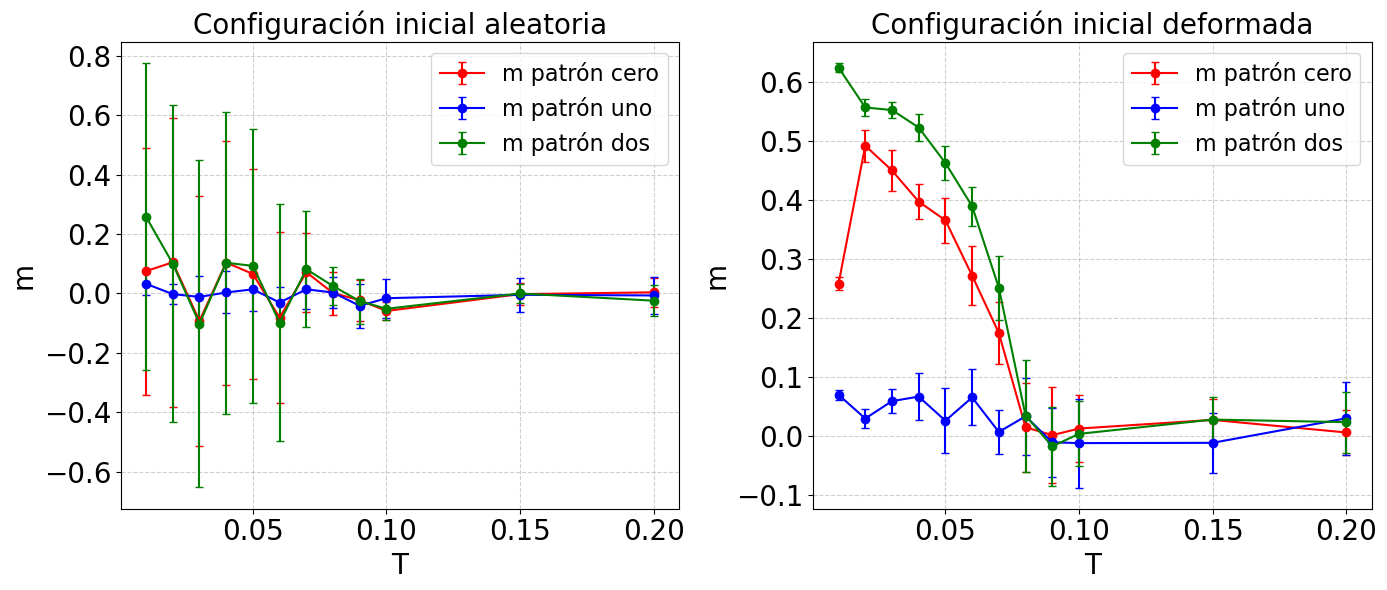

In [49]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
num_exp = 10 

# Cargar los patrones iniciales
cero = np.loadtxt("0_30.txt")
uno = np.loadtxt("1_30.txt")
dos = np.loadtxt("2_30.txt")
patrones_iniciales = [cero, uno, dos]

# Función para calcular el solapamiento 
def solapamiento(s, patrones_iniciales, N):
    m = np.zeros(len(patrones_iniciales))
    for mu in range(len(patrones_iniciales)):
        a = np.sum(patrones_iniciales[mu]) / (N * N)
        m[mu] = np.sum((patrones_iniciales[mu] - a) * (s - a)) / (N * N * a * (1 - a))
    return m

Temperaturas = [0.01,0.02,0.03,0.04,0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2]

# Listas para guardar las medias y desviaciones típicas
mean_aleatorio, std_aleatorio = [], []
mean_deformado, std_deformado = [], []

for T in Temperaturas:
    # ALEATORIO 
    datos_a = np.loadtxt(f"f_neuronas_aleatorios_varios_patrones_T_{T}.txt")
    matrices_a = datos_a.reshape(num_exp, N, N) 
    
    solap_a_exp = np.array([solapamiento(mat, patrones_iniciales, N) for mat in matrices_a])
    mean_aleatorio.append(np.mean(solap_a_exp, axis=0)) # Media de los 10 experimentos
    std_aleatorio.append(np.std(solap_a_exp, axis=0))   # Desviación típica
    
    # DEFORMADO 
    datos_d = np.loadtxt(f"f_deformado_varios_patrones_T_{T}.txt")
    matrices_d = datos_d.reshape(num_exp, N, N)
    
    solap_d_exp = np.array([solapamiento(mat, patrones_iniciales, N) for mat in matrices_d])
    mean_deformado.append(np.mean(solap_d_exp, axis=0))
    std_deformado.append(np.std(solap_d_exp, axis=0))

# Convertir a arrays para graficar fácilmente
mean_a, std_a = np.array(mean_aleatorio), np.array(std_aleatorio)
mean_d, std_d = np.array(mean_deformado), np.array(std_deformado)

# Gráfico
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for i in range(3):
    ax[0].errorbar(Temperaturas, mean_a[:, i], yerr=std_a[:, i], fmt='-o', color=colores[i], label=etiquetas[i], capsize=3)
ax[0].set_title("Configuración inicial aleatoria", fontsize=20)
ax[0].set_xlabel("T", fontsize=20)
ax[0].set_ylabel("m", fontsize=20)
ax[0].tick_params(axis="both", labelsize=20)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend(fontsize=16)

# Gráfica Deformado
for i in range(3):
    ax[1].errorbar(Temperaturas, mean_d[:, i], yerr=std_d[:, i], fmt='-o', color=colores[i], label=etiquetas[i], capsize=3)
ax[1].set_title("Configuración inicial deformada", fontsize=20)
ax[1].set_xlabel("T", fontsize=20)
ax[1].set_ylabel("m", fontsize=20)
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].tick_params(axis="both", labelsize=20)
ax[1].legend(fontsize=16)

plt.tight_layout()
plt.show()